In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.express as px
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from itertools import combinations
import os
import kaleido

In [34]:
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), "../.."))

df = pd.read_csv(os.path.join(BASE_DIR, "data", "death_rate.csv"))
print(df.info())
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year               850 non-null    int64  
 1   state              850 non-null    object 
 2   hydro_gms          850 non-null    float64
 3   oxy_gms            850 non-null    float64
 4   fent_gms           850 non-null    float64
 5   log_oxy            850 non-null    float64
 6   log_hydro          850 non-null    float64
 7   log_fent           850 non-null    float64
 8   gsp                850 non-null    float64
 9   unempl_rate        850 non-null    float64
 10  min_wage           850 non-null    float64
 11  medicaid_rate      850 non-null    float64
 12  log_gsp            850 non-null    float64
 13  log_unempl_rate    850 non-null    float64
 14  log_min_wage       850 non-null    float64
 15  log_medicaid_rate  850 non-null    float64
 16  snap_rate          850 non

,year,state,hydro_gms,oxy_gms,fent_gms,log_oxy,log_hydro,log_fent,gsp,unempl_rate,...,medicaid_rate,log_gsp,log_unempl_rate,log_min_wage,log_medicaid_rate,snap_rate,poverty_rate,gov_dem,death_rate,log_death_rate
0,2000,AL,10664.777495,6724.566122,62.816442,-0.919323,-0.397068,-0.923477,120132.9,4.6,...,0.126888,-0.293286,-0.542538,-0.980485,-0.617846,-0.385960,0.205608,1,4.4857,-1.788058
1,2001,AL,11269.214757,7735.814080,62.527727,-0.837137,-0.364056,-0.925730,123035.3,5.1,...,0.150865,-0.270620,-0.236084,-0.980485,-0.166047,-0.317086,0.983944,1,4.8915,-1.628521
2,2002,AL,12882.256134,8232.095445,83.428979,-0.800658,-0.283946,-0.784388,128117.4,5.9,...,0.164526,-0.232190,0.205498,-0.980485,0.087184,-0.162924,0.564840,1,4.7619,-1.678245
3,2003,AL,14451.140460,8704.414975,103.961016,-0.767928,-0.215127,-0.676218,133969.3,6.0,...,0.166062,-0.189783,0.257058,-0.980485,0.115471,-0.033751,0.714520,0,4.4333,-1.809515
4,2004,AL,15990.254107,9164.085680,124.175547,-0.737737,-0.154520,-0.588695,146886.7,5.7,...,0.172655,-0.102385,0.100099,-0.980485,0.236452,0.077337,1.283305,0,6.3542,-1.132777


# Clustering

## KMeans

In [ ]:
# Define the pool based on your pre-scaled columns
candidate_pool = [
    'log_oxy', 'log_fent', 
    'log_unempl_rate',
    'log_min_wage', 
    'log_gsp', 'snap_rate', 'poverty_rate', 'log_death_rate'
]

# Test different k values
k_values = [3, 4]

def find_optimal_features_multi_k(df, pool, ks, min_features=3, max_features=6):
    results = []
    
    # Pre-filter dataframe to only include pool columns to save memory in loops
    df_calc = df[pool].copy()
    
    for k in ks:
        print(f"Testing combinations for k={k}...")
        for r in range(min_features, max_features + 1):
            for combo in combinations(pool, r):
                features = list(combo)
                
                kmeans = KMeans(n_clusters=k, random_state=42, n_init=20, init="k-means++",
                                max_iter=300)
                clusters = kmeans.fit_predict(df_calc[features])
                
                score = silhouette_score(df_calc[features], clusters)
                
                results.append({
                    'k': k,
                    'feature_count': r,
                    'features': features,
                    'silhouette': score
                })
                
    return pd.DataFrame(results)

# Run the search
results_df = find_optimal_features_multi_k(df, candidate_pool, k_values)

# --- Display Top 10 for each k ---
for k in k_values:
    print(f"\n{'='*20} Top 10 Feature Sets for k={k} {'='*20}")
    top_k = results_df[results_df['k'] == k].sort_values(by='silhouette', ascending=False).head(10)
    print(top_k[['feature_count', 'silhouette', 'features']])

Testing combinations for k=3...
Testing combinations for k=4...

==================== Top 10 Feature Sets for k=3 ====================
    feature_count  silhouette                                 features
1               3    0.449758        [log_oxy, log_fent, log_min_wage]
33              3    0.415490      [log_fent, snap_rate, poverty_rate]
27              3    0.409607      [log_fent, log_min_wage, snap_rate]
23              3    0.387884   [log_fent, log_unempl_rate, snap_rate]
12              3    0.383803       [log_oxy, log_min_wage, snap_rate]
18              3    0.382696       [log_oxy, snap_rate, poverty_rate]
34              3    0.380037    [log_fent, snap_rate, log_death_rate]
3               3    0.378987           [log_oxy, log_fent, snap_rate]
5               3    0.367302      [log_oxy, log_fent, log_death_rate]
14              3    0.365558  [log_oxy, log_min_wage, log_death_rate]

==================== Top 10 Feature Sets for k=4 ====================
     feature_

In [35]:
# Define features used for clustering to ensure consistency
cluster_features = ['log_oxy', 'log_fent', 'log_min_wage']
X = df[cluster_features]

# Create two candidate clusterings
km_3 = KMeans(n_clusters=3, random_state=42, init="k-means++").fit_predict(X)
km_4 = KMeans(n_clusters=4, random_state=42, init="k-means++").fit_predict(X)

df['cluster_k3'] = km_3
df['cluster_k4'] = km_4

# calculate DB index score (want to minimize)
db_k3 = davies_bouldin_score(X, km_3)
db_k4 = davies_bouldin_score(X, km_4)

# Compare how they split the death rates
grouping_cols = ['log_death_rate', 'log_oxy', 'log_fent', 'log_gsp', 'log_min_wage']

print(f"{'='*10} 3 Clusters {'='*10}")
print(f"Davies-Bouldin Index: {db_k3:.4f}")
print(df.groupby('cluster_k3')[grouping_cols].mean())

print(f"\n{'='*10} 4 Clusters {'='*10}")
print(f"Davies-Bouldin Index: {db_k4:.4f}")
print(df.groupby('cluster_k4')[grouping_cols].mean())

========== 3 Clusters ==========
Davies-Bouldin Index: 0.8816
            log_death_rate   log_oxy  log_fent   log_gsp  log_min_wage
cluster_k3                                                            
0                 0.271779 -0.088790 -0.154042  0.018755      0.696470
1                 0.584032  1.344101  1.342052  0.393834      0.482828
2                -0.645231 -0.737091 -0.667505 -0.262851     -1.027392

========== 4 Clusters ==========
Davies-Bouldin Index: 0.9318
            log_death_rate   log_oxy  log_fent   log_gsp  log_min_wage
cluster_k4                                                            
0                 0.263450 -0.110977 -0.123098  0.042480      0.683612
1                 0.604932  1.628411  0.790054  0.447280      0.436862
2                -0.645563 -0.739517 -0.663860 -0.265295     -1.027392
3                 0.585634  0.626552  2.923936  0.071878      0.721709


| K-Value | Interpretation | Silhouette | Davies-Bouldin |
|---------|----------------|------------|----------------|
| 3 | Clusters denote general risk levels (Low, Medium, High), good broad overview | 0.449758 | 0.8816 |
| 4 | Clusters help identify specific drivers of death rate by separating High risk states into those driven by Oxy vs. those driven by Fentanyl | 0.467483 | 0.9318 |

<br>
<br>

| Cluster | Label | Description |
|---------|-------|-------------|
| 0 | Moderate Risk | States in this cluster have high relative minimum wage, below-average supplies of opioids, and a slightly-above-average death rate. This may suggest higher wages enable the purchasing of illicit drugs which increases the death rate. |
| 1 | High Risk (Prescription-Driven) | States in this cluster have the worst death rate on average, and a very high relative supply of Oxycodone (and Fentanyl, to a lesser degree), while having the highest average economic output. This cluster most commonly appears from 2006-2010, before the major spike in Fentanyl deaths in 2013. |
| 2 | Low Risk | While economic metrics (GSP, Min. Wage) are below-average, so are the supplies of Oxycodone and Fentanyl. The death rate is lowest among all clusters. |
| 3 | Acute Risk (Fentanyl-Driven) | States in this cluster have a high death rate, and most notably an extremely high supply of Fentanyl. This cluster most commonly appears from 2011-2016, during the initial spike in Fentanyl deaths. |

To determine the optimal number of clusters, we evaluated the model using three distinct metrics. The Elbow Method suggested a clear transition at $k=3$, and the Davies-Bouldin Index confirmed $k=3$ as the most compact clustering (DB: 0.8816).However, we ultimately selected $k=4$ (DB: 0.9318). Although $k=4$ slightly increased the overlap between clusters, it provided the essential clinical insight of isolating 'Fentanyl-Driven' states (Cluster 3) from 'Prescription-Driven' states (Cluster 1). This trade-off between a minor loss in mathematical tightness and a significant gain in qualitative nuance was deemed necessary to accurately represent the shifting nature of the opioid crisis.

In [36]:
# Define text labels for clusters
clustering_map = {
    0: 'Moderate Risk (Economic Protections)', # Higher wage, moderate deaths
    1: 'High Risk (Prescription-Driven)',      # Extreme Oxy levels
    2: 'Low Risk',                              # Negative values across the board
    3: 'Acute High Risk (Fentanyl-Driven)'      # Extreme Fentanyl levels
}

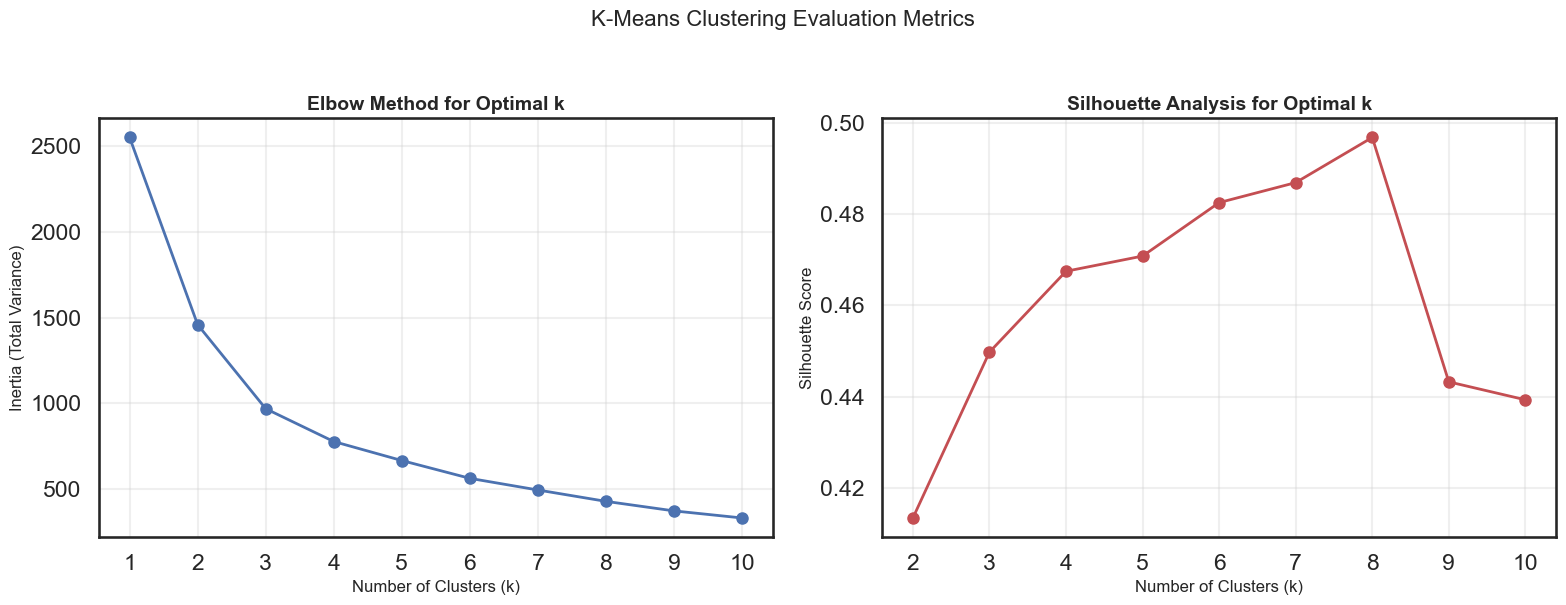

In [37]:
# KMeans Evaluation Metric Plots
cluster_features = ['log_oxy', 'log_fent', 'log_min_wage']
X = df[cluster_features]

inertia = []
sil_scores = []
K_range = range(1, 11)

# calculate metrics
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertia.append(km.inertia_)
    if k > 1:
        sil_scores.append(silhouette_score(X, labels))

# side by side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Elbow Method
ax1.plot(K_range, inertia, 'bo-', markersize=8, linewidth=2)
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Inertia (Total Variance)', fontsize=12)
ax1.set_title('Elbow Method for Optimal k', fontsize=14, fontweight='bold')
ax1.set_xticks(K_range)
ax1.grid(True, alpha=0.3)

# Silhouette Scores
ax2.plot(range(2, 11), sil_scores, 'ro-', markersize=8, linewidth=2)
ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Analysis for Optimal k', fontsize=14, fontweight='bold')
ax2.set_xticks(range(2, 11))
ax2.grid(True, alpha=0.3)

# Add a global title
plt.suptitle('K-Means Clustering Evaluation Metrics', fontsize=16, y=1.02)

plt.tight_layout()

# Save the combined plot
plt.savefig(os.path.join(BASE_DIR, "resources", "death_rate_plots", "kmeans_evaluation_metrics.png"), dpi=300, bbox_inches='tight')

plt.show()

While the Silhouette score peaked at $k=8$, the Elbow Method indicated diminishing returns after $k=4$. We chose $k=4$ as our final model because it provided the best balance between mathematical cohesion and interpretability. $k=4$ allowed us to isolate the specific 'Fentanyl-heavy' states as a unique risk group, whereas $k=8$ would have resulted in overly fragmented clusters that lacked clear policy or economic distinctions.

In [50]:
# fit the final model and grab the labels 
kmeans_final = KMeans(n_clusters=4, random_state=42, max_iter=300, n_init=20)
df['cluster_num'] = kmeans_final.fit_predict(X) 

# add text labels
df['cluster_lab'] = df['cluster_num'].map(clustering_map)

# view cluster summary
cluster_summary = df.groupby('cluster_lab')[cluster_features].mean()
print(cluster_summary)

# Sort by mortality so they print in a logical order
ordered_clusters = ['Low Risk', 'Moderate Risk (Economic Protections)', 
                    'High Risk (Prescription-Driven)', 'Acute High Risk (Fentanyl-Driven)']

for cluster in ordered_clusters:
    if cluster in df['cluster_lab'].values:
        states = df[df['cluster_lab'] == cluster]['state'].unique()
        print(f"\nStates in {cluster}: {list(states)}")

                                       log_oxy  log_fent  log_min_wage
cluster_lab                                                           
Acute High Risk (Fentanyl-Driven)     1.532550  0.863353      0.431585
High Risk (Prescription-Driven)       0.686720  3.392592      0.786432
Low Risk                             -0.741762 -0.670494     -1.027539
Moderate Risk (Economic Protections) -0.113789 -0.120383      0.686642

States in Low Risk: ['AL', 'AK', 'AZ', 'AR', 'CA', 'CO', 'CT', 'DE', 'FL', 'GA', 'HI', 'ID', 'IL', 'IN', 'IA', 'KS', 'KY', 'LA', 'ME', 'MD', 'MA', 'MI', 'MN', 'MS', 'MO', 'MT', 'NE', 'NV', 'NH', 'NJ', 'NM', 'NY', 'NC', 'ND', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VT', 'VA', 'WA', 'WV', 'WI', 'WY']

States in Moderate Risk (Economic Protections): ['AL', 'AK', 'AZ', 'AR', 'CA', 'CO', 'CT', 'DE', 'HI', 'ID', 'IL', 'IN', 'IA', 'KS', 'KY', 'LA', 'ME', 'MD', 'MA', 'MI', 'MN', 'MS', 'MT', 'NE', 'NV', 'NH', 'NM', 'ND', 'OK', 'OR', 'RI', 'SC', 'SD', 'TX'

In [8]:
# Check actual values for WV, OH to validate findings
print(df[df['state'].isin(['WV', 'OH'])].groupby('state')[['death_rate', 'log_oxy', 'log_fent', 'cluster_num']].mean())

       death_rate   log_oxy  log_fent  cluster_num
state                                             
OH      15.741453  0.672070  0.370616     1.352941
WV      24.378694  0.231092  0.178112     1.176471


In [39]:
# rank clusters on mean death rate
death_rank = df.groupby('cluster_num')['log_death_rate'].mean().sort_values().index

# map names to cluster ranks
dynamic_map = {
    death_rank[0]: 'Low Risk',
    death_rank[1]: 'Moderate Risk',
    death_rank[2]: 'High Risk (Prescription-Driven)', # Usually 2nd highest
    death_rank[3]: 'Acute High Risk (Fentanyl-Driven)' # Usually highest
}

df['cluster_lab'] = df['cluster_num'].map(dynamic_map)

# check WV, OH
print(df[df['state'].isin(['WV', 'OH'])][['state', 'year', 'cluster_lab']].tail(10))

    state  year                        cluster_lab
806    WV  2007  Acute High Risk (Fentanyl-Driven)
807    WV  2008  Acute High Risk (Fentanyl-Driven)
808    WV  2009  Acute High Risk (Fentanyl-Driven)
809    WV  2010  Acute High Risk (Fentanyl-Driven)
810    WV  2011  Acute High Risk (Fentanyl-Driven)
811    WV  2012  Acute High Risk (Fentanyl-Driven)
812    WV  2013  Acute High Risk (Fentanyl-Driven)
813    WV  2014  Acute High Risk (Fentanyl-Driven)
814    WV  2015                      Moderate Risk
815    WV  2016                      Moderate Risk


In [40]:
# Define a professional color palette for your clusters
color_discrete_map = {
    'Low Risk': '#2ecc71',                    # Green
    'Moderate Risk': '#f1c40f',               # Yellow
    'High Risk (Prescription-Driven)': '#e67e22', # Orange
    'Acute High Risk (Fentanyl-Driven)': '#e74c3c' # Red
}

In [ ]:
# Group by state and find the 'mode' (most frequent value) for the cluster labels
state_identities = df.groupby('state')['cluster_lab'].agg(lambda x: x.mode()[0]).reset_index()

fig_mode = px.choropleth(
    state_identities,
    locations='state',
    locationmode="USA-states",
    color='cluster_lab',
    scope="usa",
    title="Predominant Risk Profile (2000-2016)",
    color_discrete_map=color_discrete_map,
    category_orders={"cluster_lab": ['Low Risk', 'Moderate Risk', 
                                    'High Risk (Prescription-Driven)', 
                                    'Acute High Risk (Fentanyl-Driven)']},
)
fig_mode.update_coloraxes(showscale=False)
fig_mode.update_traces(marker_line_color="white")
fig_mode.write_image(os.path.join(BASE_DIR, "resources", "death_rate_plots", "dominant_risk_profile_map_allyears.png"))
fig_mode.show()

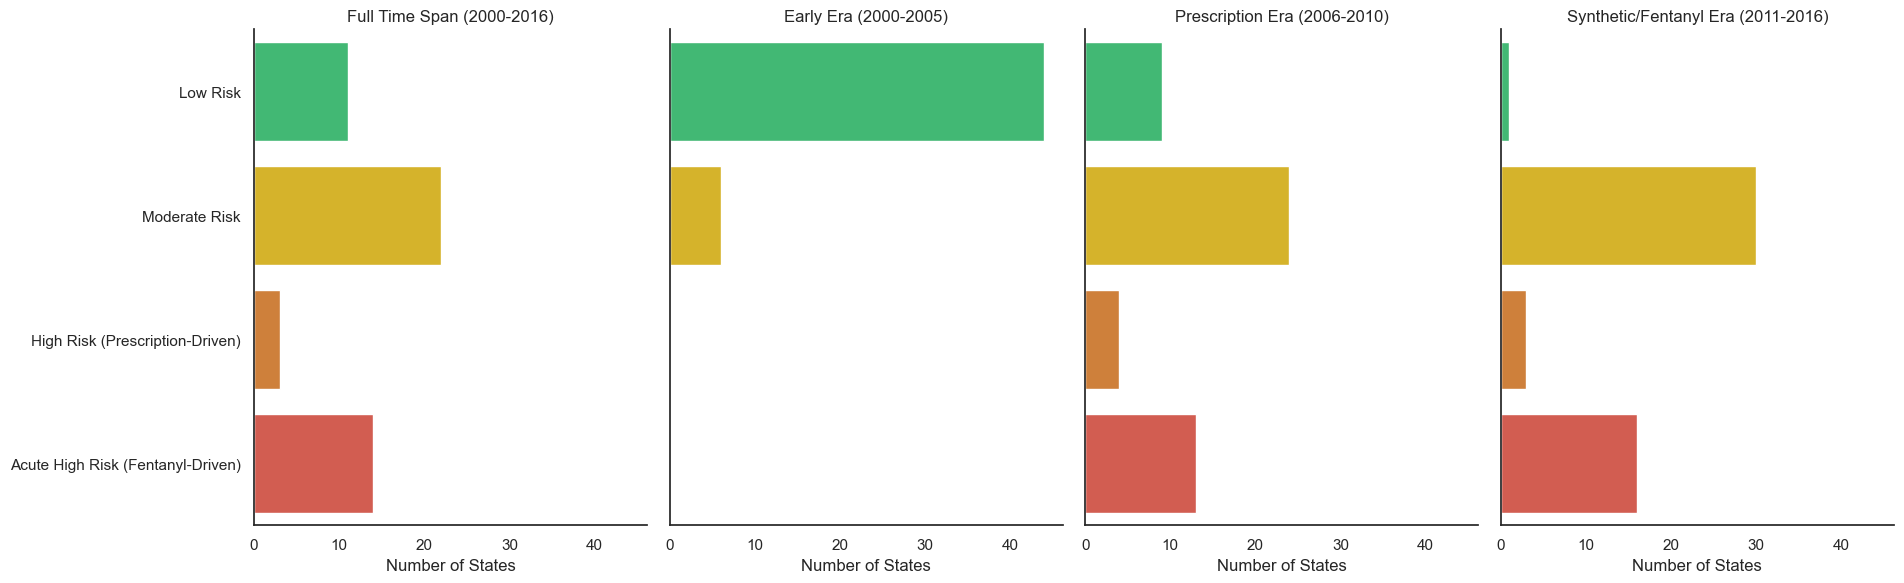

In [47]:
periods_all = [
    (2000, 2016, "Full Time Span (2000-2016)"),
    (2000, 2005, "Early Era (2000-2005)"),
    (2006, 2010, "Prescription Era (2006-2010)"),
    (2011, 2016, "Synthetic/Fentanyl Era (2011-2016)")
]

# data prep
period_data = []
for start, end, label in periods_all:
    df_slice = df[(df['year'] >= start) & (df['year'] <= end)]
    # Calculate mode for each state in this period
    modes = df_slice.groupby('state')['cluster_lab'].agg(lambda x: x.mode()[0]).reset_index()
    modes['Era'] = label
    period_data.append(modes)

# Combine into one plotting dataframe
df_eras = pd.concat(period_data)

# 2. Plotting with Seaborn
sns.set_theme(style="white")
# Create a grid: 1 row, 3 columns (one for each era)
g = sns.FacetGrid(df_eras, col="Era", height=6, aspect=0.8)

# Use a categorical plot (stripplot or barplot) to show cluster distribution per era
g.map_dataframe(sns.countplot, y="cluster_lab", hue = "cluster_lab", palette=color_discrete_map, 
                order=['Low Risk', 'Moderate Risk', 
                       'High Risk (Prescription-Driven)', 
                       'Acute High Risk (Fentanyl-Driven)'])

g.set_axis_labels("Number of States", "")
g.set_titles("{col_name}")
plt.tight_layout()

# Save the Seaborn render
plt.savefig(os.path.join(BASE_DIR, "resources", "death_rate_plots", "cluster_by_era_comp.png"), dpi=300)
plt.show()

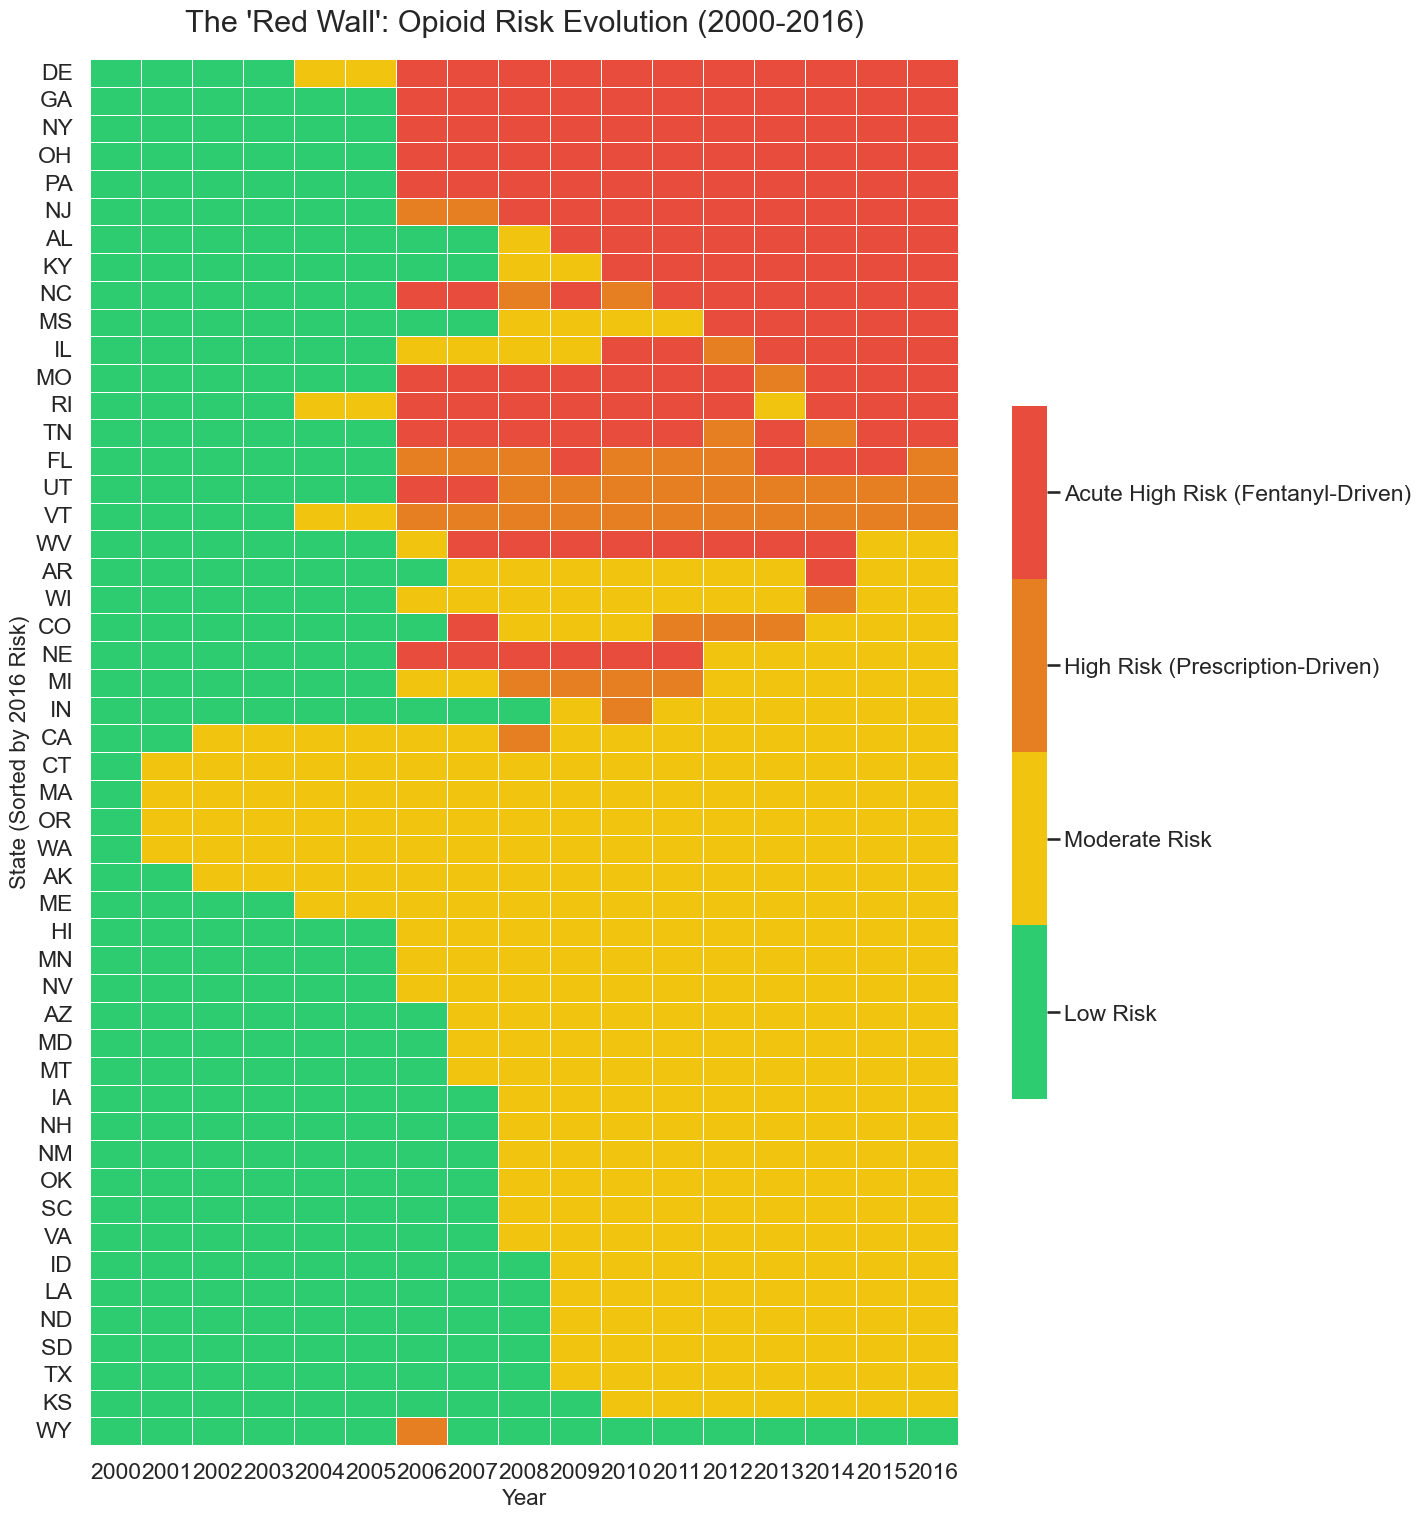

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Map labels to numerical values for the heatmap
label_order = {
    'Low Risk': 0, 
    'Moderate Risk': 1, 
    'High Risk (Prescription-Driven)': 2, 
    'Acute High Risk (Fentanyl-Driven)': 3
}
df['risk_num'] = df['cluster_lab'].map(label_order)

# 2. Pivot the data: States as rows, Years as columns
pivot_df = df.pivot(index="state", columns="year", values="risk_num")

# 3. SORT BY RISK: Sort by 2016 values first, then 2015, etc.
# This groups the 'Acute' states at the top and 'Low' at the bottom
sort_cols = sorted(df['year'].unique(), reverse=True)
pivot_df_sorted = pivot_df.sort_values(by=sort_cols, ascending=False)

# 4. Set up the plotting aesthetics
plt.figure(figsize=(14, 18)) # Height set to 18 to ensure 50 state labels are readable
sns.set_context("talk")

# Use your specific color scheme
cmap = sns.color_palette([color_discrete_map[l] for l in label_order.keys()])

# Create the Heatmap
ax = sns.heatmap(
    pivot_df_sorted, 
    cmap=cmap, 
    linewidths=.5, 
    yticklabels=True, # Forces every state label to appear
    cbar_kws={'shrink': 0.5}
)

# 5. Customize the Legend/Colorbar
colorbar = ax.collections[0].colorbar
colorbar.set_ticks([0.375, 1.125, 1.875, 2.625]) # Centers labels on the colors
colorbar.set_ticklabels(list(label_order.keys()))

plt.title("The 'Red Wall': Opioid Risk Evolution (2000-2016)", fontsize=22, pad=20)
plt.xlabel("Year", fontsize=16)
plt.ylabel("State (Sorted by 2016 Risk)", fontsize=16)

# 6. Save as high-res PNG
plt.savefig(os.path.join(BASE_DIR, "resources", "death_rate_plots", "risk_progression_heatmap_sorted.png"), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
## Side by Side Predominant Risk Profiles by Era

# define time periods
periods = [
    (2000, 2005, "Early Era (2000-2005)"),
    (2006, 2010, "Prescription Era (2006-2010)"),
    (2011, 2016, "Synthetic/Fentanyl Era (2011-2016)")
]

# Define specific color scale
custom_colorscale = [
    [0.0, '#2ecc71'],  # Low Risk
    [0.33, '#f1c40f'], # Moderate Risk
    [0.66, '#e67e22'], # High Risk
    [1.0, '#e74c3c']   # Acute Risk
]

# three side-by-side subplots
fig = make_subplots(
    rows=1, cols=3, 
    subplot_titles=[p[2] for p in periods],
    specs=[[{'type': 'choropleth'}, {'type': 'choropleth'}, {'type': 'choropleth'}]]
)

for i, (start, end, title) in enumerate(periods):
    df_slice = df[(df['year'] >= start) & (df['year'] <= end)]
    era_modes = df_slice.groupby('state')['cluster_lab'].agg(lambda x: x.mode()[0]).reset_index()
    
    # Add the map trace
    fig.add_trace(
        go.Choropleth(
            locations=era_modes['state'],
            z=era_modes['cluster_lab'].map(label_order), 
            locationmode='USA-states',
            colorscale=custom_colorscale,
            zmin=0,  # forces 0 to always be Green
            zmax=3,  # forces 3 to always be Red
            showscale=False,
            marker_line_color='white', # Sharpens the state borders
            marker_line_width=0.5
        ),
        row=1, col=i+1
    )

# 2. Lock the view to USA
fig.update_geos(scope="usa", projection_type='albers usa')

# 3. Final Layout
fig.update_layout(
    title_text="Geographic Evolution of Risk Profiles",
    title_x=0.5,
    width=1800,
    height=600,
    margin={"r":10,"t":100,"l":10,"b":10}
)

fig.write_image(os.path.join(BASE_DIR, "resources", "death_rate_plots", "state_risk_map_eras.png"))
fig.show()

In [46]:
# 3D Interactive Cluster Plots by Era

periods_full = [
    (2000, 2016, "Full Time Span (2000-2016)"),
    (2000, 2005, "Early Era (2000-2005)"),
    (2006, 2010, "Prescription Era (2006-2010)"),
    (2011, 2016, "Synthetic/Fentanyl Era (2011-2016)")
]

# Dictionary to store figures for the app
era_3d_plots = {}

for start, end, title in periods_full:
    # Filter data for the era
    df_era = df[(df['year'] >= start) & (df['year'] <= end)]
    
    fig_3d = px.scatter_3d(
        df_era, 
        x='log_oxy', 
        y='log_fent', 
        z='log_min_wage',
        color='cluster_lab',
        symbol='cluster_lab',
        hover_name='state',
        hover_data=['year', 'death_rate'],
        title=f"3D Cluster Distribution: {title}",
        color_discrete_map=color_discrete_map,
        category_orders={"cluster_lab": ['Low Risk', 'Moderate Risk', 
                                        'High Risk (Prescription-Driven)', 
                                        'Acute High Risk (Fentanyl-Driven)']}
    )
    
    # Improve the look for Streamlit
    fig_3d.update_layout(
        margin=dict(l=0, r=0, b=0, t=50),
        scene=dict(
            xaxis_title='Log Oxycodone',
            yaxis_title='Log Fentanyl',
            zaxis_title='Log Min Wage'
        ),
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
    )
    
    # Store the object (not the path!) to keep it interactive
    era_3d_plots[title] = fig_3d

In [44]:
df.head()

,year,state,hydro_gms,oxy_gms,fent_gms,log_oxy,log_hydro,log_fent,gsp,unempl_rate,...,log_medicaid_rate,snap_rate,poverty_rate,gov_dem,death_rate,log_death_rate,cluster_k3,cluster_k4,cluster_num,cluster_lab
0,2000,AL,10664.777495,6724.566122,62.816442,-0.919323,-0.397068,-0.923477,120132.9,4.6,...,-0.617846,-0.385960,0.205608,1,4.4857,-1.788058,2,2,2,Low Risk
1,2001,AL,11269.214757,7735.814080,62.527727,-0.837137,-0.364056,-0.925730,123035.3,5.1,...,-0.166047,-0.317086,0.983944,1,4.8915,-1.628521,2,2,2,Low Risk
2,2002,AL,12882.256134,8232.095445,83.428979,-0.800658,-0.283946,-0.784388,128117.4,5.9,...,0.087184,-0.162924,0.564840,1,4.7619,-1.678245,2,2,2,Low Risk
3,2003,AL,14451.140460,8704.414975,103.961016,-0.767928,-0.215127,-0.676218,133969.3,6.0,...,0.115471,-0.033751,0.714520,0,4.4333,-1.809515,2,2,2,Low Risk
4,2004,AL,15990.254107,9164.085680,124.175547,-0.737737,-0.154520,-0.588695,146886.7,5.7,...,0.236452,0.077337,1.283305,0,6.3542,-1.132777,2,2,2,Low Risk


In [17]:
# Save clustered dataframe
df.to_csv(os.path.join(BASE_DIR, "data", "death_rate_kmeans.csv"))

## DBSCAN

In [18]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

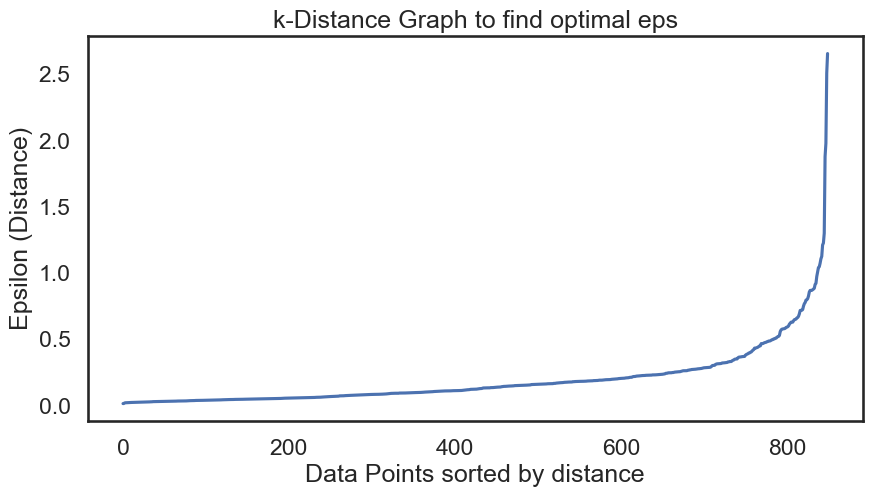

In [19]:
# We use min_samples - 1 for the nearest neighbors
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

# Sort distance and plot
distances = np.sort(distances[:, 3], axis=0)
plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title('k-Distance Graph to find optimal eps')
plt.xlabel('Data Points sorted by distance')
plt.ylabel('Epsilon (Distance)')
plt.show()

In [20]:
# DBSCAN
# Features used previously
X = df[['log_oxy', 'log_fent', 'log_min_wage']]

# Initializing DBSCAN with the 'knee' value from your graph
dbscan = DBSCAN(eps=0.5, min_samples=6)
df['dbscan_cluster'] = dbscan.fit_predict(X)

# Evaluation
n_clusters = len(set(df['dbscan_cluster'])) - (1 if -1 in df['dbscan_cluster'] else 0)
n_noise = list(df['dbscan_cluster']).count(-1)

print(f"Clusters found: {n_clusters}")
print(f"Noise points (outliers): {n_noise}")

# Show cluster members
for c in set(df['dbscan_cluster']):
    label = "Noise" if c == -1 else f"Cluster {c}"
    sample_states = df[df['dbscan_cluster'] == c]['state'].unique()[:5]
    print(f"{label}: {sample_states}")

Clusters found: 6
Noise points (outliers): 58
Cluster 0: ['AL' 'AK' 'AZ' 'AR' 'CA']
Cluster 1: ['GA' 'NE' 'NC' 'OH' 'PA']
Cluster 2: ['KS']
Cluster 3: ['MI' 'VT']
Cluster 4: ['NM' 'OH']
Noise: ['CA' 'CO' 'DE' 'FL' 'GA']


In [21]:
# Map DBSCAN results for 2016
fig_dbscan = px.choropleth(
    df[df['year'] == 2016],
    locations='state',
    locationmode="USA-states",
    color='dbscan_cluster',
    scope="usa",
    # Use a divergent scale or discrete map to highlight -1 (Noise)
    color_continuous_scale="Viridis", 
    title="DBSCAN Density Clusters & Outliers (2016)"
)
fig_dbscan.show()

## Hierarchical Clustering

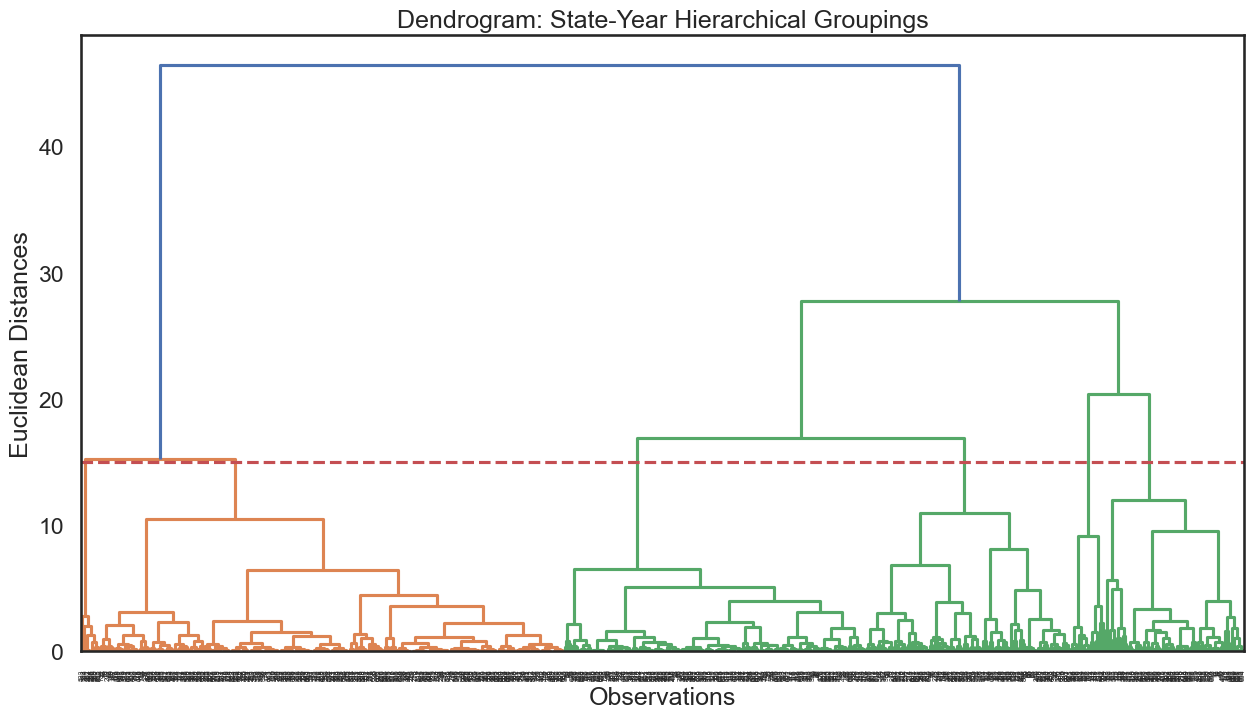

In [22]:
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

# Features from your previous steps
X = df[['log_oxy', 'log_fent', 'log_min_wage']]

# 1. Generate the Linkage Matrix (using Ward's method to minimize variance)
plt.figure(figsize=(15, 8))
dendrogram = sch.dendrogram(sch.linkage(X, method='ward'))

plt.title('Dendrogram: State-Year Hierarchical Groupings')
plt.xlabel('Observations')
plt.ylabel('Euclidean Distances')
plt.axhline(y=15, color='r', linestyle='--') # Example "cut" line
plt.show()